#### Step 9 - Model Evaluation and Comparison
##### Input: y_test, predictions from both models
##### Process: Side by side comparison of Logistic Regression vs Random Forest
##### Output: Comparison table and confusion matrices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

y_test = np.load('../Data/y_test.npy')


y_pred_lr = np.load('../Data/y_pred_lr.npy')
y_pred_rf = np.load('../Data/y_pred_rf.npy')

In [2]:
lr_report = classification_report(y_test, y_pred_lr, 
                                   target_names=['Fatal','Serious','Slight'], 
                                   output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, 
                                   target_names=['Fatal','Serious','Slight'], 
                                   output_dict=True)

comparison = pd.DataFrame({
    'LR F1': [lr_report['Fatal']['f1-score'],
              lr_report['Serious']['f1-score'],
              lr_report['Slight']['f1-score']],
    'RF F1': [rf_report['Fatal']['f1-score'],
              rf_report['Serious']['f1-score'],
              rf_report['Slight']['f1-score']],
    'LR Recall': [lr_report['Fatal']['recall'],
                  lr_report['Serious']['recall'],
                  lr_report['Slight']['recall']],
    'RF Recall': [rf_report['Fatal']['recall'],
                  rf_report['Serious']['recall'],
                  rf_report['Slight']['recall']]
}, index=['Fatal','Serious','Slight'])

print(comparison.round(2))

         LR F1  RF F1  LR Recall  RF Recall
Fatal     0.07   0.11       0.63       0.19
Serious   0.27   0.35       0.28       0.38
Slight    0.67   0.79       0.56       0.76


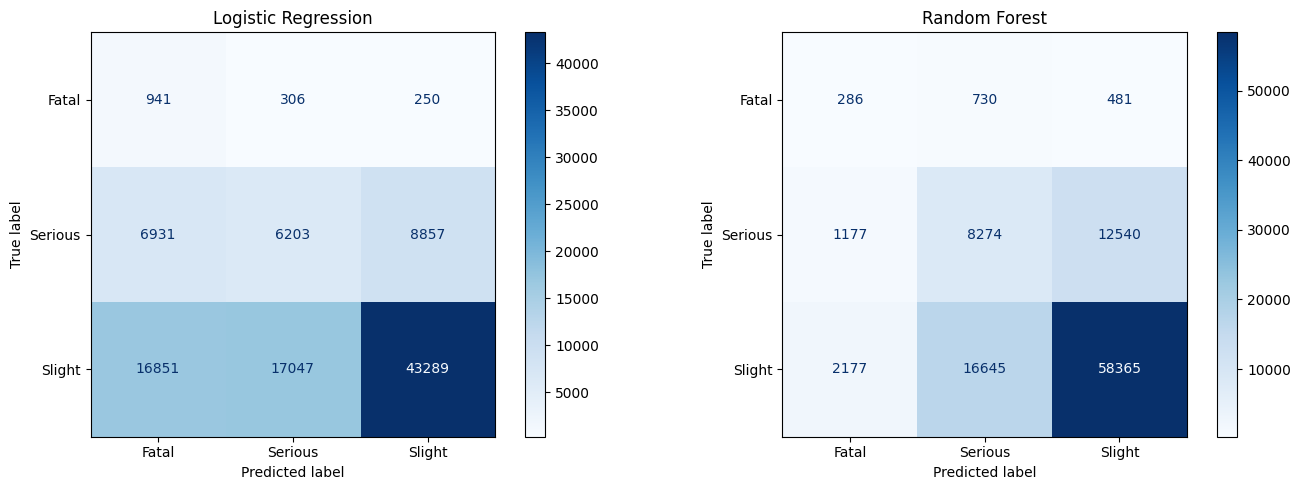

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Fatal','Serious','Slight'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Fatal','Serious','Slight'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig('../Output/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Evaluation Summary

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 50% | 66% |
| Fatal F1 | 0.07 | 0.11 |
| Serious F1 | 0.27 | 0.35 |
| Slight F1 | 0.67 | 0.79 |

- Random Forest outperforms Logistic Regression on every class
- Fatal remains the hardest class to predict due to severe class imbalance
- Random Forest is the recommended model for deployment
- For road safety applications Fatal Recall is the most critical metric